In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/ColabDatasets/house_prices.csv')


In [ ]:
data.head()


,Unnamed: 0,property_type,price,location,city,baths,purpose,bedrooms,Area_in_Marla
0,0,Flat,10000000,G-10,Islamabad,2,For Sale,2,4.0
1,1,Flat,6900000,E-11,Islamabad,3,For Sale,3,5.6
2,2,House,16500000,G-15,Islamabad,6,For Sale,5,8.0
3,3,House,43500000,Bani Gala,Islamabad,4,For Sale,4,40.0
4,4,House,7000000,DHA Defence,Islamabad,3,For Sale,3,8.0


In [ ]:
data.shape
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99499 entries, 0 to 99498
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     99499 non-null  int64  
 1   property_type  99499 non-null  object 
 2   price          99499 non-null  int64  
 3   location       99499 non-null  object 
 4   city           99499 non-null  object 
 5   baths          99499 non-null  int64  
 6   purpose        99499 non-null  object 
 7   bedrooms       99499 non-null  int64  
 8   Area_in_Marla  99499 non-null  float64
dtypes: float64(1), int64(4), object(4)
memory usage: 6.8+ MB


In [ ]:
data.isnull().sum()


,0
Unnamed: 0,0
property_type,0
price,0
location,0
city,0
baths,0
purpose,0
bedrooms,0
Area_in_Marla,0


In [ ]:
data.duplicated().sum()


np.int64(0)

data.corr(numeric_only=True)

In [ ]:
data.corr(numeric_only=True)

,Unnamed: 0,price,baths,bedrooms,Area_in_Marla
Unnamed: 0,1.000000,-0.007957,0.001672,-0.015748,0.061182
price,-0.007957,1.000000,0.496222,0.464393,0.145644
baths,0.001672,0.496222,1.000000,0.863885,0.373993
bedrooms,-0.015748,0.464393,0.863885,1.000000,0.352021
Area_in_Marla,0.061182,0.145644,0.373993,0.352021,1.000000


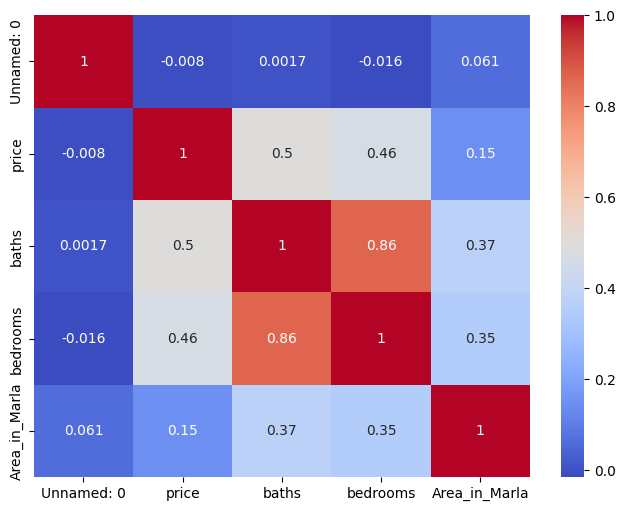

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()


In [ ]:
if 'Unnamed: 0' in data.columns:
    data.drop('Unnamed: 0', axis=1, inplace=True)
data.head()

,property_type,price,location,city,baths,purpose,bedrooms,Area_in_Marla
0,Flat,10000000,G-10,Islamabad,2,For Sale,2,4.0
1,Flat,6900000,E-11,Islamabad,3,For Sale,3,5.6
2,House,16500000,G-15,Islamabad,6,For Sale,5,8.0
3,House,43500000,Bani Gala,Islamabad,4,For Sale,4,40.0
4,House,7000000,DHA Defence,Islamabad,3,For Sale,3,8.0


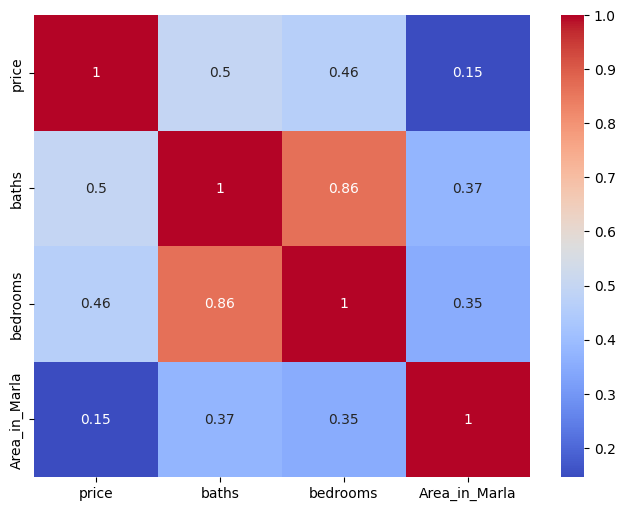

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()


In [ ]:
data.select_dtypes(include='object').columns


Index(['property_type', 'location', 'city', 'purpose'], dtype='object')

In [ ]:
data['purpose'].value_counts()


,count
purpose,
For Sale,70947
For Rent,28552


In [ ]:


data_sal = data[data['purpose'] == 'For Sale']
data_sal.head()

,property_type,price,location,city,baths,purpose,bedrooms,Area_in_Marla
0,Flat,10000000,G-10,Islamabad,2,For Sale,2,4.0
1,Flat,6900000,E-11,Islamabad,3,For Sale,3,5.6
2,House,16500000,G-15,Islamabad,6,For Sale,5,8.0
3,House,43500000,Bani Gala,Islamabad,4,For Sale,4,40.0
4,House,7000000,DHA Defence,Islamabad,3,For Sale,3,8.0


In [ ]:
data_sal['price_category'] = pd.cut(
    data_sal['price'],
    bins=[0, 5000000, 10000000, 20000000, 50000000],
    labels=['Low', 'Medium', 'High', 'Very High']
)


/tmp/ipython-input-77336819.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_sal['price_category'] = pd.cut(


In [ ]:
data_sal['area_category'] = pd.cut(
    data_sal['Area_in_Marla'],
    bins=[0, 5, 10, 20, 50],
    labels=['Small', 'Medium', 'Large', 'Very Large']
)


/tmp/ipython-input-1090823819.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_sal['area_category'] = pd.cut(


In [ ]:
apriori_data = data_sal[
    ['property_type', 'city', 'location', 'bedrooms', 'price_category', 'area_category']
].astype(str)


In [ ]:
from mlxtend.preprocessing import TransactionEncoder

transactions = apriori_data.values.tolist()

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)

df_transactions = pd.DataFrame(te_ary, columns=te.columns_)


In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules

frequent_itemsets = apriori(
    df_transactions,
    min_support=0.05,
    use_colnames=True
)

frequent_itemsets.sort_values(by='support', ascending=False).head()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,support,itemsets
10,0.690966,(House)
16,0.599166,(Medium)
18,0.468758,(Small)
69,0.404245,"(House, Medium)"
12,0.383526,(Karachi)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.6
)

rules.sort_values(by='confidence', ascending=False).head()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
14,(Bahria Town Karachi),(Karachi),0.087544,0.383526,0.087544,1.0,2.607387,1.0,0.053969,inf,0.675621,0.228262,1.0,0.614131
48,"(3, Bahria Town Karachi)",(Karachi),0.061454,0.383526,0.061454,1.0,2.607387,1.0,0.037885,inf,0.656840,0.160235,1.0,0.580118
135,"(3, Medium, Bahria Town Karachi)",(Karachi),0.057635,0.383526,0.057635,1.0,2.607387,1.0,0.035530,inf,0.654178,0.150276,1.0,0.575138
130,"(House, 3, Bahria Town Karachi)",(Karachi),0.050347,0.383526,0.050347,1.0,2.607387,1.0,0.031038,inf,0.649158,0.131275,1.0,0.565638
82,"(House, Bahria Town Karachi)",(Karachi),0.055436,0.383526,0.055436,1.0,2.607387,1.0,0.034175,inf,0.652655,0.144542,1.0,0.572271


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
import pandas as pd
from sklearn.metrics import pairwise_distances
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)

df_transactions = pd.DataFrame(te_ary, columns=te.columns_)
df_transactions.head()


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,0,1,12th Avenue,2,204 Chak Road,3,4,5,6,7th Avenue,...,Zaraj Housing Scheme,Zeeshan Colony,Zero Point,Zia Colony,Zone 5,Zubaida Park,Zubair Colony,Zulfiqar Colony,circular road,nan
0,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
data_sal.shape


(70947, 8)

In [ ]:
data_encoded = pd.get_dummies(
    data_sal,
    columns=['property_type', 'location', 'city'],
    drop_first=True
)
data_encoded=data_encoded.drop('purpose', axis=1)

print(data_encoded.head())

      price  baths  bedrooms  Area_in_Marla  property_type_Flat  \
0  10000000      2         2            4.0                True   
1   6900000      3         3            5.6                True   
2  16500000      6         5            8.0               False   
3  43500000      4         4           40.0               False   
4   7000000      3         3            8.0               False   

   property_type_House  property_type_Lower Portion  property_type_Penthouse  \
0                False                        False                    False   
1                False                        False                    False   
2                 True                        False                    False   
3                 True                        False                    False   
4                 True                        False                    False   

   property_type_Room  property_type_Upper Portion  ...  location_Zia Colony  \
0               False               

In [ ]:
X = data_encoded.drop('price', axis=1)
y = data_encoded['price']
print(y )
print(X)

0        10000000
1         6900000
2        16500000
3        43500000
4         7000000
           ...   
99494     7500000
99495     8800000
99496    14000000
99497    14000000
99498     9000000
Name: price, Length: 70947, dtype: int64
       baths  bedrooms  Area_in_Marla  property_type_Flat  \
0          2         2            4.0                True   
1          3         3            5.6                True   
2          6         5            8.0               False   
3          4         4           40.0               False   
4          3         3            8.0               False   
...      ...       ...            ...                 ...   
99494      3         3            8.0                True   
99495      4         3            8.0               False   
99496      3         3            8.0               False   
99497      4         4           14.0               False   
99498      3         3            9.4               False   

       property_type_House  

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)


MAE: 3598197.2220379272


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("Model Accuracy (R² Score):", r2)


Model Accuracy (R² Score): 0.7029836817966515


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)




RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
rf_pred = rf_model.predict(X_test)

print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))
print("Random Forest MSE:", mean_squared_error(y_test, rf_pred))
print("Random Forest R2 Score:", r2_score(y_test, rf_pred))

Random Forest MAE: 2270143.759361422
Random Forest MSE: 13290873405924.943
Random Forest R2 Score: 0.8654083665769389


In [ ]:
import pandas as pd
import numpy as np

def predict_house_price(
    area,
    bedrooms,
    baths,
    property_type,
    city,
    location
):
    # 1️⃣ Empty dataframe with same columns
    input_df = pd.DataFrame(
        np.zeros((1, len(X.columns))),
        columns=X.columns
    )

    # 2️⃣ Fill numerical values
    input_df['Area_in_Marla'] = area
    input_df['bedrooms'] = bedrooms
    input_df['baths'] = baths

    # 3️⃣ One-hot encoded columns set karo
    if f'property_type_{property_type}' in input_df.columns:
        input_df[f'property_type_{property_type}'] = 1

    if f'city_{city}' in input_df.columns:
        input_df[f'city_{city}'] = 1

    if f'location_{location}' in input_df.columns:
        input_df[f'location_{location}'] = 1

    # 4️⃣ Scaling
    input_scaled = scaler.transform(input_df)

    # 5️⃣ Prediction
    predicted_price = rf_model.predict(input_scaled)

    return predicted_price[0]


In [ ]:
# 🔹 Take inputs from user
area = float(input("Enter area (in Marla): "))
bedrooms = int(input("Enter number of bedrooms: "))
baths = int(input("Enter number of bathrooms: "))
property_type = input("Enter property type (e.g. House, Flat): ")
city = input("Enter city (e.g. Lahore, Karachi): ")
location = input("Enter location (e.g. DHA Phase 5): ")

# 🔹 Predict price
price = predict_house_price(
    area=area,
    bedrooms=bedrooms,
    baths=baths,
    property_type=property_type,
    city=city,
    location=location
)

print("\nEstimated House Price:", round(price))


Enter area (in Marla): 10
Enter number of bedrooms: 3
Enter number of bathrooms: 3
Enter property type (e.g. House, Flat): Flat
Enter city (e.g. Lahore, Karachi): Karachi
Enter location (e.g. DHA Phase 5): Bahria Town Karachi

Estimated House Price: 11865788


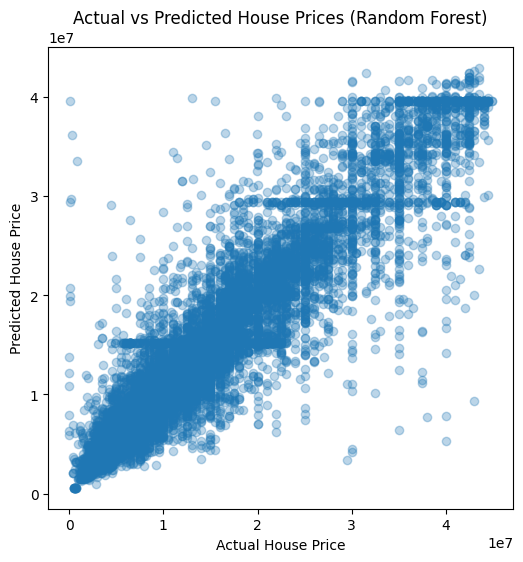

In [ ]:
import matplotlib.pyplot as plt

# Random Forest predictions
rf_pred = rf_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred, alpha=0.3)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices (Random Forest)")
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

rf_tuned = RandomForestRegressor(
    n_estimators=500,        # zyada trees
    max_depth=25,            # depth limit
    min_samples_leaf=5,      # leaves me averaging
    random_state=42,
    n_jobs=-10sa32/;
)

rf_tuned.fit(X_train, y_train)

rf_tuned_pred = rf_tuned.predict(X_test)

print("Tuned RF MAE:", mean_absolute_error(y_test, rf_tuned_pred))
print("Tuned RF R2:", r2_score(y_test, rf_tuned_pred))


Tuned RF MAE: 2544340.1336184395
Tuned RF R2: 0.8439996861868946


In [ ]:
data_sal[data_sal['location'] == 'Bahria Town Karachi']['price'].describe()


,price
count,6.211000e+03
mean,1.230725e+07
std,5.266066e+06
min,3.000000e+05
25%,7.300000e+06
50%,1.250000e+07
75%,1.490000e+07
max,4.200000e+07


In [ ]:
import joblib
joblib.dump(rf_model, 'rf_house_price_model.pkl')


['rf_house_price_model.pkl']

In [ ]:
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [ ]:
joblib.dump(X.columns.tolist(), 'model_features.pkl')


['model_features.pkl']

In [ ]:
from google.colab import files

files.download('rf_house_price_model.pkl')
files.download('scaler.pkl')
files.download('model_features.pkl')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>